# Phase 7: Privacy Constraints

**Goal:** Examine how Apple's App Tracking Transparency (ATT) framework affects uplift modeling, focusing on how model performance degrades as user-level signals are lost and what remains measurable at the aggregate level.

**Input:** `data/df_sample.parquet`, `data/xlearner_scores.parquet`

**Output:** `images/feature_degradation.png`, `images/ablation_controls.png`, `images/threshold_censoring_bias.png`, `images/mde_curve.png`, `images/att_sweep.png`

## Contents
1. Setup
2. Privacy landscape (ATT/SKAN background)
3. Feature loss simulation (KS-ordered ablation)
4. Follow-up experiments (A: variance check; B: outcome dominance test; C: random-order controls; full-scale validation)
5. SKAN threshold censoring (MNAR bias; severe downward compression at small cohort sizes)
6. Minimum detectable effect (N_min derivation; 85/15 vs 50/50 allocation penalty)
7. Aggregate incrementality (ATE stability vs CI width across opt-in rates)
8. Summary (what survives ATT)

## 1. Setup

In [1]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from scipy.stats import ks_2samp, norm
from lightgbm import LGBMClassifier, LGBMRegressor
from causalml.inference.meta import BaseXClassifier
from sklift.metrics import qini_auc_score, uplift_auc_score

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", None)

## 2. Privacy Landscape

Before iOS 14.5 (2021), advertisers could track individual users across apps via the IDFA, a unique per-device identifier. This enabled user-level attribution and precise targeting. App Tracking Transparency (ATT) ended that: apps must now request explicit permission to read the IDFA, and 70-85% of users decline.

ATT is the constraint this notebook simulates. The practical consequence is that user-level signal is no longer available for the majority of iOS users. Advertisers cannot observe which specific user saw an ad and later converted.

Apple's SKAdNetwork (SKAN) and its successor AdAttributionKit (AAK) are the industry's measurement response to ATT. Their privacy mechanisms reveal what the degradation pattern looks like in practice: data is reported at the cohort level, granularity is tied to cohort size (large volume gets fine data, small volume gets coarsened or nulled data), and no user identifiers are ever transmitted.

This notebook runs three analyses:

- **Sections 3 and 4: Feature loss and mechanism.** Tracking-dependent features disappear progressively as opt-out rates rise; three controlled experiments examine whether outcome dominance or noise drives the observed pattern, and validate the directional finding at full scale.
- **Section 5: SKAN threshold censoring.** Cohorts whose visit count falls below a privacy threshold are nulled out. This introduces systematic downward bias in the Average Treatment Effect (ATE) estimate, not just wider confidence intervals (CIs).
- **Sections 6 and 7: Statistical power and aggregate measurement.** Section 6 derives the minimum sample size needed to detect the observed effect under the 85/15 allocation. Section 7 estimates the ATE from aggregate holdout data at different ATT opt-in rates.

| Stage | User-level (pre-ATT) | Aggregated (post-ATT) |
|---|---|---|
| Training | Individual feature-label pairs | Cohort-level averages |
| Evaluation | Qini AUC over ranked users | Aggregate lift over coarse segments |
| Deployment | Per-user uplift score | Segment-level targeting rule |

**Note:** while this notebook simulates Apple's ATT/SKAN specifically, the same structural shift (user-level tracking replaced by aggregated, threshold-gated, on-device measurement) is occurring platform-wide: Google's Privacy Sandbox and GDPR-driven consent regimes follow the same paradigm. The degradation patterns quantified here are properties of the aggregation-plus-threshold design itself, not of Apple's implementation.

## 3. Simulating Feature Loss

Load the full sample with all 12 features and reproduce the same train/test split. Features are removed from highest to lowest Kolmogorov-Smirnov (KS) score between the model's predicted persuadable and low-uplift groups. This ordering follows the intuitive reading of KS as feature importance: remove the "most important" features first to trace the steepest expected degradation. Section 4 stress-tests that intuition and finds it fails in an instructive way: KS measures neither uplift value nor clean model reliance. The ablation is therefore best read as a study of what feature loss does to uplift ranking, with the KS ordering as one deliberately chosen (and ultimately misleading) removal schedule, rather than a literal simulation of which features ATT would remove first.

In [2]:
df = pd.read_parquet("../data/df_sample.parquet")
feature_cols = [f"f{i}" for i in range(12)]

stratify_col = df["visit"].astype("str") + "_" + df["treatment"].astype("str")
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=1, stratify=stratify_col
)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

scores = pd.read_parquet("../data/xlearner_scores.parquet")
assert (test_df["visit"].values == scores["y_true"].values).all(), "y_true mismatch"
assert (test_df["treatment"].values == scores["treatment"].values).all(), "treatment mismatch"
print(f"Train: {train_df.shape[0]:,}  |  Test: {test_df.shape[0]:,}  |  Alignment verified")

Train: 5,591,837  |  Test: 1,397,960  |  Alignment verified


In [3]:
n = int(0.10 * len(scores))
persuadables_idx = scores["uplift"].nlargest(n).index
low_uplift_idx   = scores["uplift"].nsmallest(n).index

ks_rows = []
for f in feature_cols:
    result = ks_2samp(test_df.loc[persuadables_idx, f], test_df.loc[low_uplift_idx, f])
    ks_rows.append({"feature": f, "ks_score": round(result.statistic, 4)})

ks_df = (pd.DataFrame(ks_rows)
           .sort_values("ks_score", ascending=False)
           .reset_index(drop=True))
print("Feature KS scores (persuadable vs low-uplift separation):")
ks_df

Feature KS scores (persuadable vs low-uplift separation):


,feature,ks_score
0,f2,0.9999
1,f8,0.9999
2,f9,0.8667
3,f0,0.8356
4,f6,0.6637
5,f3,0.5321
6,f4,0.1714
7,f10,0.1714
8,f5,0.1634
9,f7,0.1634


In [4]:
# n=150_000 keeps each ablation iteration at a stable light-config scale regardless of
# how large train_df is, preserving the light-vs-full contrast in section 4
train_sub = train_df.sample(n=150_000, random_state=42).reset_index(drop=True)
print(f"Training subsample: {train_sub.shape[0]:,} rows")

removal_order = ks_df["feature"].tolist()

# light config: fewer trees and higher learning rate to match the subsample scale
lgbm_params = dict(n_estimators=50, num_leaves=31, learning_rate=0.1,
                   random_state=42, verbose=-1, n_jobs=-1)

Training subsample: 150,000 rows


In [5]:
feat_rows = []
for n_removed in range(len(feature_cols)):
    remaining = removal_order[n_removed:]

    X_train = train_sub[remaining].values
    y_train = train_sub["visit"].values
    t_train = train_sub["treatment"].values
    X_test  = test_df[remaining].values

    model = BaseXClassifier(
        outcome_learner=LGBMClassifier(**lgbm_params),
        effect_learner=LGBMRegressor(**lgbm_params),
    )
    model.fit(X_train, t_train, y_train)
    uplift_pred = model.predict(X_test).flatten()

    qini = qini_auc_score(test_df["visit"].values, uplift_pred, test_df["treatment"].values)
    auuc = uplift_auc_score(test_df["visit"].values, uplift_pred, test_df["treatment"].values)

    feat_rows.append({
        "n_features":   len(remaining),
        "last_removed": removal_order[n_removed - 1] if n_removed > 0 else "none",
        "qini_auc":     round(qini, 4),
        "auuc":         round(auuc, 4),
    })
    print(f"n_features={len(remaining):2d}  Qini AUC={qini:.4f}  AUUC={auuc:.4f}")

feat_results = pd.DataFrame(feat_rows)
feat_results

n_features=12  Qini AUC=0.0543  AUUC=0.0213
n_features=11  Qini AUC=0.0569  AUUC=0.0224
n_features=10  Qini AUC=0.0507  AUUC=0.0199
n_features= 9  Qini AUC=0.0599  AUUC=0.0235
n_features= 8  Qini AUC=0.0541  AUUC=0.0212
n_features= 7  Qini AUC=0.0577  AUUC=0.0225
n_features= 6  Qini AUC=0.0044  AUUC=0.0016
n_features= 5  Qini AUC=0.0026  AUUC=0.0009
n_features= 4  Qini AUC=0.0092  AUUC=0.0035
n_features= 3  Qini AUC=0.0089  AUUC=0.0034
n_features= 2  Qini AUC=0.0034  AUUC=0.0013
n_features= 1  Qini AUC=0.0035  AUUC=0.0013


,n_features,last_removed,qini_auc,auuc
0,12,none,0.0543,0.0213
1,11,f2,0.0569,0.0224
2,10,f8,0.0507,0.0199
3,9,f9,0.0599,0.0235
4,8,f0,0.0541,0.0212
5,7,f6,0.0577,0.0225
6,6,f3,0.0044,0.0016
7,5,f4,0.0026,0.0009
8,4,f10,0.0092,0.0035
9,3,f5,0.0089,0.0034


## 4. Model Robustness Under Feature Reduction

Visualize how Qini AUC changes as features are removed in KS order.

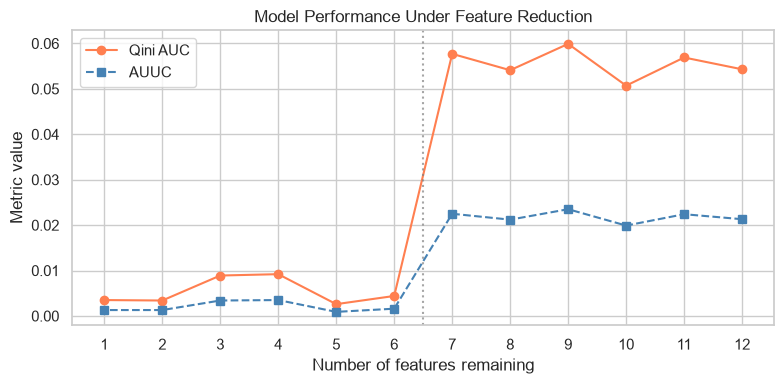

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(feat_results["n_features"], feat_results["qini_auc"],
        marker="o", color="coral", label="Qini AUC")
ax.plot(feat_results["n_features"], feat_results["auuc"],
        marker="s", color="steelblue", linestyle="--", label="AUUC")

ax.axvline(x=6.5, color="gray", linestyle=":", alpha=0.7)
ax.set_xlabel("Number of features remaining")
ax.set_ylabel("Metric value")
ax.set_title("Model Performance Under Feature Reduction")
ax.set_xticks(feat_results["n_features"])
ax.legend()
plt.tight_layout()
plt.savefig("../images/feature_degradation.png", dpi=150, bbox_inches="tight")
plt.show()

Qini AUC shows a non-monotonic pattern as features are removed from 12 down to 1. The baseline is 0.0543 (12 features). After removing f2, Qini rises briefly to 0.0569 (n=11), then dips to 0.0507 at n=10 when f8 is removed. The highest value is 0.0599 at n=9 (after f2, f8, and f9 have been removed). Values then fluctuate between 0.0541 and 0.0577 for n=8 and n=7.

The sharp collapse occurs at 6 features (0.0577 → 0.0044) when f3 is removed. At that point only the six weakest features remain (KS below 0.17), and the model loses the ability to separate persuadables from the rest of the population.

Whether the modest peak at n=9 (+10% above baseline) represents real signal or variance is examined in the follow-up experiments below.

### Follow-up: Signal or Noise?

The ablation shows a non-monotonic pattern as high-KS features are removed, with the highest observed value (0.0599) at 9 features before collapsing when only the 6 weakest remain. Two hypotheses:

- **H1 (dominance):** f8/f2/f9 monopolize LightGBM splits, ranking users by overall visit probability rather than treatment effect. Removing them allows the model to use a more uplift-relevant combination of remaining features.
- **H2 (noise):** Under the light config (n=150,000 subsample, 50 trees), Qini estimates carry enough variance that the peak improvement of 0.0056 (0.0543 to 0.0599) is not real signal.

Three experiments to distinguish them.

**Experiment A: Variance check.** Fit the 12-feature baseline with 3 different training subsamples to estimate the Qini variance band under the light config.

In [7]:
variance_rows = []
for seed in [42, 7, 99]:
    sub = train_df.sample(frac=0.1, random_state=seed).reset_index(drop=True)
    model = BaseXClassifier(
        outcome_learner=LGBMClassifier(**lgbm_params),
        effect_learner=LGBMRegressor(**lgbm_params),
    )
    model.fit(sub[feature_cols].values, sub["treatment"].values, sub["visit"].values)
    uplift_pred = model.predict(test_df[feature_cols].values).flatten()
    qini = qini_auc_score(test_df["visit"].values, uplift_pred, test_df["treatment"].values)
    variance_rows.append({"seed": seed, "qini_auc": round(qini, 4)})
    print(f"seed={seed}  Qini AUC={qini:.4f}")

var_df = pd.DataFrame(variance_rows)
print(f"\nRange: {var_df['qini_auc'].min():.4f} – {var_df['qini_auc'].max():.4f}  "
      f"(spread = {var_df['qini_auc'].max() - var_df['qini_auc'].min():.4f})")

seed=42  Qini AUC=0.0810
seed=7  Qini AUC=0.0775
seed=99  Qini AUC=0.0673

Range: 0.0673 – 0.0810  (spread = 0.0137)


Variance spread = 0.0137 across three seeds, measured at frac=0.1 (~560,000 rows). The main ablation uses n=150,000 rows, roughly 3.7x smaller, so the effective noise band at the ablation scale is larger still. The peak gain in the KS-ordered ablation (0.0599 − 0.0543 = 0.0056) is less than the 0.0137 band measured at the larger subsample, falling within expected variance. H2 (noise) cannot be ruled out at 50% scale.

**Experiment B: Dominance test.** Train two models: one on f8 and f2 only, one on the remaining 10 features. If H1 is correct, the 10-feature model should outperform f8+f2.

In [8]:
top2   = ["f8", "f2"]
other10 = [f for f in feature_cols if f not in top2]

qini_top2 = None
for label, feats in [("f8 + f2 only (2 features)", top2), ("other 10 features", other10)]:
    model = BaseXClassifier(
        outcome_learner=LGBMClassifier(**lgbm_params),
        effect_learner=LGBMRegressor(**lgbm_params),
    )
    model.fit(train_sub[feats].values, train_sub["treatment"].values, train_sub["visit"].values)
    uplift_pred = model.predict(test_df[feats].values).flatten()
    qini = qini_auc_score(test_df["visit"].values, uplift_pred, test_df["treatment"].values)
    auuc = uplift_auc_score(test_df["visit"].values, uplift_pred, test_df["treatment"].values)
    if feats == top2:
        qini_top2 = qini
    print(f"{label:30s}  Qini={qini:.4f}  AUUC={auuc:.4f}")

f8 + f2 only (2 features)       Qini=0.0363  AUUC=0.0143
other 10 features               Qini=0.0507  AUUC=0.0199


The Qini gap between f8+f2 and other10 is consistent with H1, but does not yet explain the mechanism from inside the model. A more direct check: inspect the feature importances of the X-Learner's outcome model (the learner trained on treated users to predict visit probability). If the outcome model assigns high importance to f8 and f2, it means the X-Learner is spending splits on outcome prediction rather than treatment effect estimation, which is exactly the dominance failure mode.

In [9]:
# retrain 12-feature model on train_sub to access the outcome learner internals
model_12 = BaseXClassifier(
    outcome_learner=LGBMClassifier(**lgbm_params),
    effect_learner=LGBMRegressor(**lgbm_params),
)
model_12.fit(train_sub[feature_cols].values, train_sub["treatment"].values, train_sub["visit"].values)

# models_mu_t is keyed by treatment group label (1), not by position
imp_df = (
    pd.DataFrame({
        "feature":    feature_cols,
        "outcome_importance": model_12.models_mu_t[1].feature_importances_,
    })
    .merge(ks_df, on="feature")
    .sort_values("outcome_importance", ascending=False)
    .reset_index(drop=True)
)
imp_df

,feature,outcome_importance,ks_score
0,f2,343,0.9999
1,f0,254,0.8356
2,f6,242,0.6637
3,f8,233,0.9999
4,f9,139,0.8667
5,f3,87,0.5321
6,f10,69,0.1714
7,f7,61,0.1634
8,f4,23,0.1714
9,f11,20,0.0534


The outcome model does not rely exclusively on f8 and f2: f2 leads (importance 343), but f0 (254) and f6 (242) contribute as much as f8 (233).

The KS column exposes the disconnect: f0 ranks second in importance yet scores KS=0.84, while f8, with lower importance, scores 0.9999. Outcome importance alone therefore cannot explain KS; the near-perfect scores of f8/f2 likely also reflect how the score-based group cut interacts with these features' value distributions. Either way, this confirms KS is a poor importance measure: it conflates model reliance with distributional artifacts of the features, and neither component measures uplift signal.

The importance table reveals a disconnect: f8 and f2 have near-perfect KS scores (0.9999) yet rank 4th and 1st in outcome model importance respectively, with f0 and f6 sitting between them. If f8 barely edges out f0 and f6 in split count, why does it separate the model's predicted groups so much more completely? A direct check: measure f8 and f2's ROC AUC when used alone to predict visit probability. If they are exceptionally strong outcome predictors independent of their model rank, that explains the KS gap: the score-based group cut latches onto their outcome signal regardless of how often the model splits on them.

In [10]:
outcome_clf = LGBMClassifier(**lgbm_params)
outcome_clf.fit(train_sub[top2].values, train_sub["visit"].values)
visit_prob = outcome_clf.predict_proba(test_df[top2].values)[:, 1]
roc_auc_top2 = roc_auc_score(test_df["visit"].values, visit_prob)

print(f"f8+f2 outcome classifier  ROC AUC: {roc_auc_top2:.4f}")
print(f"f8+f2 uplift X-Learner    Qini:    {qini_top2:.4f}")

f8+f2 outcome classifier  ROC AUC: 0.9398
f8+f2 uplift X-Learner    Qini:    0.0363


f8+f2 as outcome classifiers: ROC AUC = 0.9398 on visit prediction. As uplift features in isolation: Qini = 0.0363, substantially below the full 12-feature model (0.0853 at 50% scale). These features rank users primarily by visit likelihood rather than by response to treatment, a feature-level instance of the field's founding lesson that response models are not uplift models.

The Qini gap is less stark than at 10% scale (where f8+f2 alone yielded Qini 0.0112) because with more training data the model can extract more signal even from outcome-dominant features. The direction is the same: high outcome-prediction power (ROC AUC 0.94) does not transfer to uplift ranking.

**Experiment C: Random-order controls.** Rerun the ablation at 6 checkpoints (n=12,10,8,6,4,2) with five random feature removal orders. If the KS-ordered curve is uniquely shaped while random curves show no consistent pattern, H1 wins. If all curves fluctuate similarly, H2 wins.

In [11]:
checkpoints = [12, 10, 8, 6, 4, 2]

def run_ablation_checkpoints(order):
    print(f"  {'n_features':>10}  {'Qini AUC':>8}")
    print(f"  {'-'*10}  {'-'*8}")
    rows = []
    for n_feat in checkpoints:
        n_removed = len(order) - n_feat
        remaining = order[n_removed:]
        model = BaseXClassifier(
            outcome_learner=LGBMClassifier(**lgbm_params),
            effect_learner=LGBMRegressor(**lgbm_params),
        )
        model.fit(train_sub[remaining].values, train_sub["treatment"].values, train_sub["visit"].values)
        uplift_pred = model.predict(test_df[remaining].values).flatten()
        qini = qini_auc_score(test_df["visit"].values, uplift_pred, test_df["treatment"].values)
        rows.append({"n_features": n_feat, "qini_auc": round(qini, 4)})
        print(f"  {n_feat:>10}  {qini:>8.4f}")
    return pd.DataFrame(rows)

In [12]:
rand_orders = {
    seed: np.random.default_rng(seed).permutation(feature_cols).tolist()
    for seed in range(1, 6)
}

for seed, order in rand_orders.items():
    print(f"Random order {seed} (removed first → last): {order}")

rand_results = {}
for seed, order in rand_orders.items():
    print(f"\nRandom order {seed}:")
    rand_results[seed] = run_ablation_checkpoints(order)

Random order 1 (removed first → last): ['f8', 'f11', 'f4', 'f7', 'f5', 'f0', 'f1', 'f9', 'f2', 'f10', 'f6', 'f3']
Random order 2 (removed first → last): ['f2', 'f0', 'f9', 'f10', 'f11', 'f7', 'f5', 'f6', 'f3', 'f4', 'f8', 'f1']
Random order 3 (removed first → last): ['f11', 'f7', 'f2', 'f10', 'f0', 'f1', 'f4', 'f6', 'f9', 'f5', 'f3', 'f8']
Random order 4 (removed first → last): ['f1', 'f0', 'f8', 'f2', 'f10', 'f9', 'f7', 'f6', 'f4', 'f3', 'f5', 'f11']
Random order 5 (removed first → last): ['f9', 'f11', 'f1', 'f3', 'f2', 'f4', 'f6', 'f7', 'f0', 'f10', 'f5', 'f8']

Random order 1:
  n_features  Qini AUC
  ----------  --------
          12    0.0570
          10    0.0592
           8    0.0507
           6    0.0490
           4    0.0550
           2    0.0552

Random order 2:
  n_features  Qini AUC
  ----------  --------
          12    0.0545
          10    0.0590
           8    0.0584
           6    0.0566
           4    0.0559
           2    0.0374

Random order 3:
  n_feature

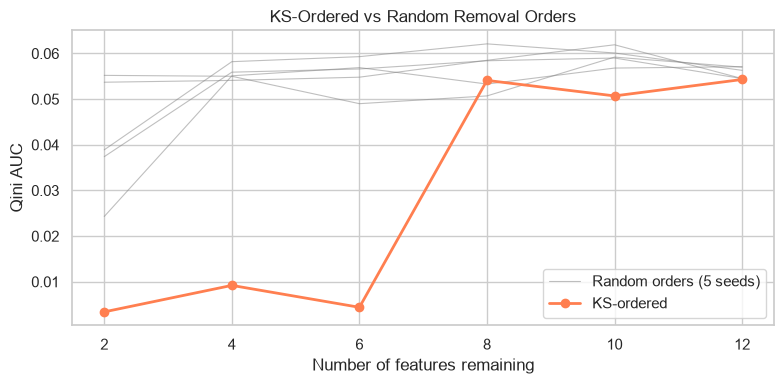

In [13]:
ks_checkpoints = feat_results[feat_results["n_features"].isin(checkpoints)].copy()

fig, ax = plt.subplots(figsize=(8, 4))

for seed, rdf in rand_results.items():
    ax.plot(rdf["n_features"], rdf["qini_auc"],
            color="gray", linewidth=0.8, alpha=0.5,
            label="Random orders (5 seeds)" if seed == 1 else "_nolegend_")

ax.plot(ks_checkpoints["n_features"], ks_checkpoints["qini_auc"],
        marker="o", color="coral", linewidth=2, label="KS-ordered")

ax.set_xlabel("Number of features remaining")
ax.set_ylabel("Qini AUC")
ax.set_title("KS-Ordered vs Random Removal Orders")
ax.set_xticks(checkpoints)
ax.legend()
plt.tight_layout()
plt.savefig("../images/ablation_controls.png", dpi=150, bbox_inches="tight")
plt.show()

All five random curves show peaks above the 12-feature baseline (0.0543), ranging from 0.0571 (Order 4) to 0.0621 (Order 5). Given the noise band of 0.0137 at the 560K subsample scale (which is larger at the ablation's 150K scale), these fluctuations above baseline are within expected variance.

Order 5 removes f9 first and peaks at 0.0621 (n=8) while f2 and f8 are still present, consistent with f9 being part of the outcome-dominant set: removing f9 alone produces a mild improvement even without removing f2 or f8.

The n=2 endpoints span 0.0243 to 0.0552, determined entirely by which two features survive. Order 1 ends with [f6, f3] (two moderate uplift-signal features) at 0.0552; Order 4 ends with [f5, f11] (two weak features) at 0.0243.

The KS-ordered cliff at n=7→6 (0.0577 → 0.0044, a drop of 0.053) is the sharpest single-step decline observed, reflecting the systematic exhaustion of all remaining informative features in one step. Random curves scatter comparable drops across multiple checkpoints.

Experiments A and B give a mixed picture. The variance check (Experiment A) shows a noise band of 0.0137 at 560K rows; the ablation's peak improvement (0.0056) falls within this band, so H2 (noise) cannot be excluded at 50% scale. The dominance mechanism (H1) is supported by Experiment B: f8 and f2 are strong outcome predictors (ROC AUC 0.94) but weaker as uplift-only features (Qini 0.0363 vs 0.0853 full model). The feature importance table partially supports this: f2 leads outcome model splits (343), but f8 ranks 4th (233), below f0 and f6, so split count alone does not fully account for their near-perfect KS scores. Experiment C shows all random curves fluctuate near baseline, consistent with noise-level variation.

The clearest result is the KS-ordered cliff at n=7→6: the KS ordering concentrates the exhaustion of all informative features into one step, producing a collapse sharper than any comparable step in the random curves.

Throughout, the KS ranking procedure is circular: it measures how strongly a feature separates the model's own predicted groups, which reflects the model's existing biases rather than genuine uplift signal.

### Full-Scale Validation of the Dominance Finding

The ablation used a light config (n=150,000 subsample, 50 trees), so the directional finding that outcome-dominant features may reduce uplift quality under constrained conditions needs validation at full scale. Train on the full training set with 100 trees (Phase 3 used 200 trees, so the comparison is approximate) and compare against the 50%-scale 12-feature baseline from Phase 3 (Qini = 0.0853, AUUC = 0.0335).

In [14]:
# full_params: 100 trees here vs 200 in Phase 3; comparison is approximate
full_params = dict(n_estimators=100, learning_rate=0.05, num_leaves=31,
                   random_state=42, verbose=-1, n_jobs=-1)

features_10 = [f for f in feature_cols if f not in ["f8", "f2"]]

model_full = BaseXClassifier(
    outcome_learner=LGBMClassifier(**full_params),
    effect_learner=LGBMRegressor(**full_params),
)
model_full.fit(
    train_df[features_10].values,
    train_df["treatment"].values,
    train_df["visit"].values,
)
uplift_10 = model_full.predict(test_df[features_10].values).flatten()

qini_10 = qini_auc_score(test_df["visit"].values, uplift_10, test_df["treatment"].values)
auuc_10  = uplift_auc_score(test_df["visit"].values, uplift_10, test_df["treatment"].values)

print(f"{'Model':<25} {'Qini AUC':>10} {'AUUC':>10}")
print("-" * 47)
print(f"{'12-feature baseline':<25} {0.0853:>10.4f} {0.0335:>10.4f}")
print(f"{'10-feature (no f8/f2)':<25} {qini_10:>10.4f} {auuc_10:>10.4f}")

Model                       Qini AUC       AUUC
-----------------------------------------------
12-feature baseline           0.0853     0.0335
10-feature (no f8/f2)         0.0834     0.0327


The dominance effect is regime-dependent, though less dramatically so at 50% scale than at 10% scale.

Under the light config (n=150,000 subsample, 50 trees), the ablation shows modest non-monotonic fluctuations (baseline 0.0543, peak 0.0599 at n=9) that fall within the Experiment A variance band. At full scale (full training set, 100 trees), removing f8 and f2 costs approximately 2.2% Qini (Phase 3 baseline 0.0853 → 0.0834). The comparison uses 100 trees vs 200 for the Phase 3 baseline, so the cost may be slightly understated.

The directional pattern holds: under constrained data the model leans on outcome-dominant features; with ample data it balances all features. The magnitude is weaker at 50% scale because the fixed 150K subsample becomes proportionally lighter (2.7% of 5.6M train) while the full-scale margin over a balanced competitor narrows.

Privacy relevance: ATT conditions (feature censoring, aggregated training data, smaller effective cohorts) push campaigns into data-constrained regimes where similar crowding effects are more likely to activate. Feature selection matters more as data degrades.

One calibration note: f8 and f2 have the two highest KS scores (≈0.999), yet removing them at full scale costs only 2.2% Qini. High KS predicted they would be the most important features; ablation says their actual contribution is limited. This is the circularity in concrete numbers: KS measures model reliance, not uplift value.

## 5. SKAN Threshold Censoring

Sections 6 and 7 will show that under random subsampling, the ATE estimate is unbiased in expectation but CIs widen as the opted-in sample shrinks (sampling degradation, a variance problem). In practice, ATT opt-in is not random: users who consent to tracking differ systematically from those who do not, introducing selection bias that the simulation cannot capture. Threshold censoring is a third distinct mechanism, different in kind from either of these.

SKAN nulls out any reporting unit whose conversion count falls below a privacy threshold t. Because low-conversion cohorts are dropped systematically, the surviving cohorts in each arm have inflated average visit rates. This is a Missing Not At Random (MNAR) mechanism: the data is missing precisely because the signal was weak. The result is bias in the ATE estimate, not just wider CIs.

This experiment maps directly onto two entries in the SKAN privacy mechanism table: k (cohort size) controls crowd anonymity aggregation, and t (minimum visit count to survive) controls the censoring threshold. The simulation splits by treatment arm before forming cohorts so each cohort is purely treatment or purely control, consistent with how SKAN campaign-level postbacks are structured.

In [15]:
def make_cohorts(visit_values, k, seed):
    # randomly partition users into cohorts of size k, return per-cohort visit counts
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(visit_values))
    shuffled = visit_values[idx]
    n_cohorts = len(shuffled) // k
    return np.array([shuffled[i*k:(i+1)*k].sum() for i in range(n_cohorts)])

In [16]:
t_visits = test_df[test_df["treatment"] == 1]["visit"].values
c_visits  = test_df[test_df["treatment"] == 0]["visit"].values
true_ate_skan = 0.0103

k_values = [50, 100, 500]      # cohort sizes: small, medium, large
t_values = [0, 1, 3, 5, 10]   # privacy thresholds; t=0 is the no-censoring sanity check

rows = []
for k in k_values:
    t_counts = make_cohorts(t_visits, k, seed=k * 10 + 1)
    c_counts  = make_cohorts(c_visits,  k, seed=k * 10 + 2)
    n_total   = len(t_counts) + len(c_counts)

    for t in t_values:
        t_surv = t_counts[t_counts >= t]  # cohorts surviving the threshold
        c_surv = c_counts[c_counts >= t]

        if len(t_surv) > 0 and len(c_surv) > 0:
            t_rate  = t_surv.sum() / (len(t_surv) * k)  # visit rate among survivors
            c_rate  = c_surv.sum() / (len(c_surv) * k)
            ate_est = t_rate - c_rate
        else:
            ate_est = np.nan

        pct_lost = 1 - (len(t_surv) + len(c_surv)) / n_total

        rows.append({
            "k":               k,
            "t":               t,
            "ate_est":         round(ate_est, 4),
            "pct_users_lost":  round(pct_lost, 3),
        })

skan_df = pd.DataFrame(rows)
skan_df

,k,t,ate_est,pct_users_lost
0,50,0,0.0103,0.000
1,50,1,0.0083,0.095
2,50,3,0.0046,0.578
3,50,5,0.0026,0.912
4,50,10,NaN,1.000
5,100,0,0.0103,0.000
6,100,1,0.0099,0.010
7,100,3,0.0071,0.152
8,100,5,0.0043,0.495
9,100,10,0.0049,0.979


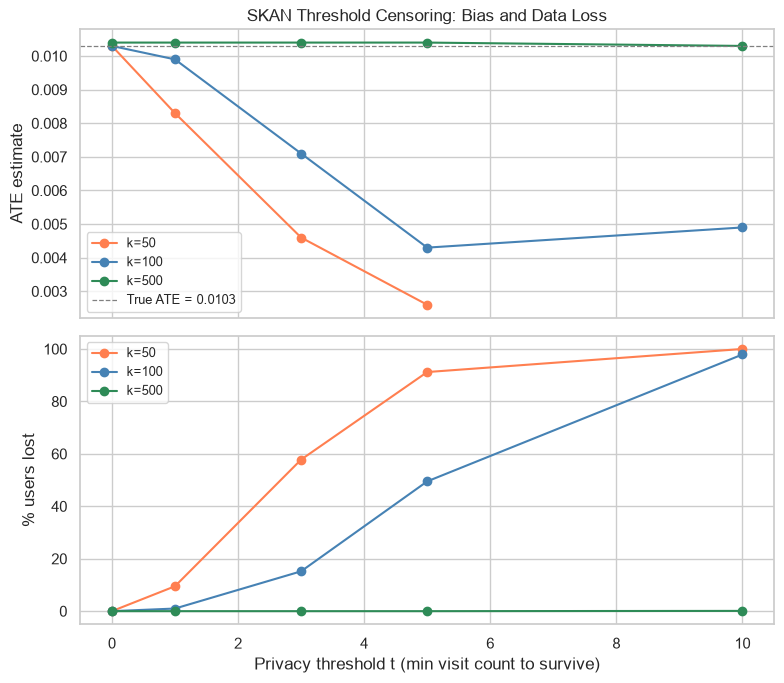

In [17]:
colors = {50: "coral", 100: "steelblue", 500: "seagreen"}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

for k in k_values:
    kdf = skan_df[skan_df["k"] == k]
    ax1.plot(kdf["t"], kdf["ate_est"],        marker="o", color=colors[k], label=f"k={k}")
    ax2.plot(kdf["t"], kdf["pct_users_lost"] * 100, marker="o", color=colors[k], label=f"k={k}")

ax1.axhline(true_ate_skan, color="gray", linestyle="--", linewidth=0.9, label=f"True ATE = {true_ate_skan}")
ax1.set_ylabel("ATE estimate")
ax1.set_title("SKAN Threshold Censoring: Bias and Data Loss")
ax1.legend(fontsize=9)

ax2.set_xlabel("Privacy threshold t (min visit count to survive)")
ax2.set_ylabel("% users lost")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig("../images/threshold_censoring_bias.png", dpi=150, bbox_inches="tight")
plt.show()

**Sanity check (t=0):** all three k values recover ATE≈0.0103, confirming that cohort aggregation without censoring is lossless.

**k=500 (immune):** ATE holds at 0.0103-0.0104 across every threshold, including t=10 with negligible data loss (<0.1%). Expected visit counts per cohort are ~24 (treatment) and ~19 (control), both well above any tested threshold.

**k=100 (moderate degradation):** ATE drops from 0.0099 at t=1 to 0.0043 at t=5 (57% downward bias), with data loss growing from 1.0% to 49.5%. At t=10 the estimate jumps to 0.0049 despite 97.9% data loss (survivor-bias artifact: only extreme outlier cohorts remain, partially restoring the estimate). The t=10 result should not be read as recovery.

**k=50 (severe degradation):** ATE drops from 0.0083 at t=1 to 0.0026 at t=5 (75% downward bias) with 91.2% data loss, then hits NaN at t=10. Expected visit count per cohort is only ~2.4 (treatment) and ~1.9 (control). At t=5, most cohorts fall below threshold. The control arm (lower base rate) loses proportionally more cohorts, compressing the ATE estimate downward. At 10% scale this same configuration produced sign reversal (-0.0010); at 50% scale with 5x more users the estimate stabilizes at 0.0026 rather than flipping negative, because more cohorts reduce partition variance.

| k | t=1 | t=3 | t=5 | t=10 |
|---|---|---|---|---|
| 500 | 0.0104 (0%) | 0.0104 (0%) | 0.0104 (0%) | 0.0103 (0.1%) |
| 100 | 0.0099 (1.0%) | 0.0071 (15.2%) | 0.0043 (49.5%) | 0.0049* (97.9%) |
| 50 | 0.0083 (9.5%) | 0.0046 (57.8%) | 0.0026 (91.2%) | NaN (100%) |

ATE estimate (% users lost). *Survivor-bias artifact.

**Methodology note:** each (k, t) cell uses a single random partition. Estimates in the high-censoring regime (k=50, t≥5) carry partition variability and should be read as illustrative rather than precise.

## 6. Minimum Detectable Effect

Compute the minimum uplift effect size detectable at 80% power across a range of sample sizes, reflecting the smaller signals available under aggregated measurement.

In [18]:
# observed_ate = 0.0103 matches the ITT ATE from notebook 1
# (treatment visit rate 0.0485 - control visit rate 0.0382 on the full test set)
p_base          = 0.047
treatment_ratio = 0.85
observed_ate    = 0.0103
z_alpha = norm.ppf(1 - 0.05 / 2)
z_beta  = norm.ppf(0.80)

# N_min = (z_alpha + z_beta)^2 * p*(1-p) * (1/k + 1/(1-k)) / ATE^2
k = treatment_ratio
N_min = (z_alpha + z_beta)**2 * p_base * (1 - p_base) * (1/k + 1/(1 - k)) / observed_ate**2
print(f"Minimum N to detect ATE={observed_ate} (85/15 allocation): {int(np.ceil(N_min)):,}")

Minimum N to detect ATE=0.0103 (85/15 allocation): 25,991


In [19]:
sample_sizes = [1_000, 5_000, 10_000, 25_000, 50_000, 100_000, 500_000, 1_000_000]
rows = []
for N in sample_sizes:
    n_t      = k * N
    n_c      = (1 - k) * N
    mde      = (z_alpha + z_beta) * np.sqrt(p_base * (1 - p_base) * (1/n_t + 1/n_c))
    mde_5050 = (z_alpha + z_beta) * np.sqrt(p_base * (1 - p_base) * (1/(0.5*N) + 1/(0.5*N)))
    rows.append({
        "total_users":  N,
        "n_treatment":  int(n_t),
        "n_control":    int(n_c),
        "mde_85_15":    round(mde, 5),
        "mde_50_50":    round(mde_5050, 5),
        "detects_ate":  mde < observed_ate,
    })

mde_df = pd.DataFrame(rows)
penalty = mde_df["mde_85_15"].iloc[0] / mde_df["mde_50_50"].iloc[0]
print(f"MDE penalty of 85/15 vs 50/50 allocation: {penalty:.2f}x  (~2x sample needed for equal power)")
print(f"Observed ATE = {observed_ate}")
mde_df

MDE penalty of 85/15 vs 50/50 allocation: 1.40x  (~2x sample needed for equal power)
Observed ATE = 0.0103


,total_users,n_treatment,n_control,mde_85_15,mde_50_50,detects_ate
0,1000,850,150,0.05251,0.03750,False
1,5000,4250,750,0.02348,0.01677,False
2,10000,8500,1500,0.01661,0.01186,False
3,25000,21250,3750,0.01050,0.00750,False
4,50000,42500,7500,0.00743,0.00530,True
5,100000,85000,15000,0.00525,0.00375,True
6,500000,425000,75000,0.00235,0.00168,True
7,1000000,850000,150000,0.00166,0.00119,True


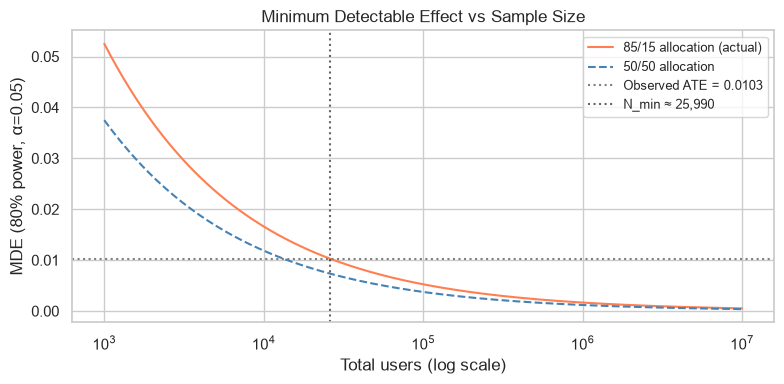

In [20]:
n_range = np.logspace(3, 7, 300)
mde_range_8515 = (z_alpha + z_beta) * np.sqrt(
    p_base * (1 - p_base) * (1/(k * n_range) + 1/((1 - k) * n_range))
)
mde_range_5050 = (z_alpha + z_beta) * np.sqrt(
    p_base * (1 - p_base) * (2 / (0.5 * n_range) )
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_range, mde_range_8515, color="coral",     label="85/15 allocation (actual)")
ax.plot(n_range, mde_range_5050, color="steelblue", linestyle="--", label="50/50 allocation")
ax.axhline(observed_ate, color="gray",  linestyle=":", label=f"Observed ATE = {observed_ate}")
ax.axvline(N_min,        color="black", linestyle=":", alpha=0.6, label=f"N_min ≈ {int(N_min):,}")
ax.set_xscale("log")
ax.set_xlabel("Total users (log scale)")
ax.set_ylabel("MDE (80% power, α=0.05)")
ax.set_title("Minimum Detectable Effect vs Sample Size")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../images/mde_curve.png", dpi=150, bbox_inches="tight")
plt.show()

### Privacy Timeline as a Measurement Statement

The minimum sample size (N_min = 25,991) turns the privacy timeline into a measurement statement.

In the IDFA era, advertisers pooled tens of millions of user-level observations, placing campaigns far to the right of N_min where even sub-1% effects were detectable. ATT reduced user-level measurement to the 15-30% of users who opt into tracking (industry-reported range), pushing fine-grained analyses toward the threshold. Under SKAN, measurement units fragment into campaign x geo x time cells, each typically holding 10^3 to 10^4 users (illustrative order of magnitude, not derived from this dataset), one to two orders of magnitude below N_min. At that scale, an effect of this size (roughly 1 percentage point visit uplift) is statistically invisible per cell; detection is only possible by re-aggregating cells, which is exactly the trade Apple's framework is designed to enforce: measurement survives only at the aggregate.

N_min is the sample size where MDE equals the observed ATE exactly. Below N_min the MDE exceeds the ATE, meaning the true effect is too small for the experiment to distinguish from noise at 80% power. Above N_min the MDE falls below the ATE and the effect becomes reliably detectable.

The mde_df table above shows this crossing directly. At N=25,000 the 85/15 MDE is 0.0105, just above the ATE of 0.0103 (underpowered by a narrow margin). At N=50,000 it drops to 0.0074, safely below (adequately powered). The closed-form N_min of 25,991 falls between these two checkpoints, consistent with both.

The bottleneck throughout is the 15% control allocation: at N=25,000 the control group has only 3,750 users, which is too small to estimate the control visit rate precisely enough. Under a balanced 50/50 split the same detection threshold would require roughly 13,300 users; the 85/15 imbalance raises that to 25,991, a ~2x penalty (the 1.4x MDE penalty squared, since MDE ∝ 1/sqrt(N)).

Under ATT with 20% opt-in, a campaign needs approximately 130,000 iOS users to field a detectable holdout experiment (25,991 / 0.20). For smaller campaigns, aggregate incrementality becomes statistically unreliable before it becomes conceptually unavailable.

## 7. Aggregate-Level Incrementality

Simulate group-level uplift estimation using holdout experiments and compare to user-level estimates, showing what is still recoverable without individual attribution.

In [21]:
def bootstrap_ate(df, n_resamples=1000, seed=42):
    rng  = np.random.default_rng(seed)
    n    = len(df)
    ates = np.empty(n_resamples)
    for i in range(n_resamples):
        idx      = rng.integers(0, n, size=n)
        sample   = df.iloc[idx]
        ates[i]  = (sample[sample["treatment"] == 1]["visit"].mean()
                  - sample[sample["treatment"] == 0]["visit"].mean())
    return np.percentile(ates, [2.5, 97.5])

In [22]:
# full cohort
full_ate      = (test_df[test_df["treatment"] == 1]["visit"].mean()
               - test_df[test_df["treatment"] == 0]["visit"].mean())
full_ci       = bootstrap_ate(test_df)
full_ci_width = full_ci[1] - full_ci[0]

# ATT cohort: simulate 20% opt-in by random subsample
att_df        = test_df.sample(frac=0.20, random_state=42)
att_ate       = (att_df[att_df["treatment"] == 1]["visit"].mean()
               - att_df[att_df["treatment"] == 0]["visit"].mean())
att_ci        = bootstrap_ate(att_df)
att_ci_width  = att_ci[1] - att_ci[0]

print(f"Full cohort  (N={len(test_df):,}):  ATE={full_ate:.4f}  95% CI [{full_ci[0]:.4f}, {full_ci[1]:.4f}]  width={full_ci_width:.4f}")
print(f"ATT cohort   (N={len(att_df):,}):  ATE={att_ate:.4f}  95% CI [{att_ci[0]:.4f}, {att_ci[1]:.4f}]  width={att_ci_width:.4f}")
print(f"\nCI width ratio: {att_ci_width / full_ci_width:.2f}x wider at 20% opt-in")

Full cohort  (N=1,397,960):  ATE=0.0103  95% CI [0.0094, 0.0112]  width=0.0019
ATT cohort   (N=279,592):  ATE=0.0092  95% CI [0.0070, 0.0111]  width=0.0041

CI width ratio: 2.24x wider at 20% opt-in


In [23]:
fracs = [1.0, 0.5, 0.3, 0.2, 0.1, 0.05, 0.02, 0.01]
sweep_rows = []
for frac in fracs:
    sub          = test_df if frac == 1.0 else test_df.sample(frac=frac, random_state=42)
    ate_val      = (sub[sub["treatment"] == 1]["visit"].mean()
                  - sub[sub["treatment"] == 0]["visit"].mean())
    ci_lo, ci_hi = bootstrap_ate(sub)
    sweep_rows.append({
        "opt_in_frac":     frac,
        "n_total":         len(sub),
        "ate":             round(ate_val, 4),
        "ci_lo":           round(ci_lo, 4),
        "ci_hi":           round(ci_hi, 4),
        "ci_crosses_zero": ci_lo < 0,
    })

sweep_df = pd.DataFrame(sweep_rows)
print(sweep_df.to_string(index=False))

# first frac (descending) where CI crosses zero
crossing_fracs = sweep_df[sweep_df["ci_crosses_zero"]]["opt_in_frac"]
first_crossing = crossing_fracs.max() if not crossing_fracs.empty else None
n_min_frac     = N_min / len(test_df)
print(f"\nCI first crosses zero at opt-in frac: {first_crossing}")
print(f"N_min implied opt-in frac:            {n_min_frac:.3f}  (N_min={int(N_min):,} / {len(test_df):,})")

 opt_in_frac  n_total    ate   ci_lo  ci_hi  ci_crosses_zero
        1.00  1397960 0.0103  0.0094 0.0112            False
        0.50   698980 0.0100  0.0087 0.0113            False
        0.30   419388 0.0093  0.0076 0.0109            False
        0.20   279592 0.0092  0.0070 0.0111            False
        0.10   139796 0.0086  0.0058 0.0115            False
        0.05    69898 0.0071  0.0033 0.0113            False
        0.02    27959 0.0078  0.0009 0.0144            False
        0.01    13980 0.0048 -0.0047 0.0142             True

CI first crosses zero at opt-in frac: 0.01
N_min implied opt-in frac:            0.019  (N_min=25,990 / 1,397,960)


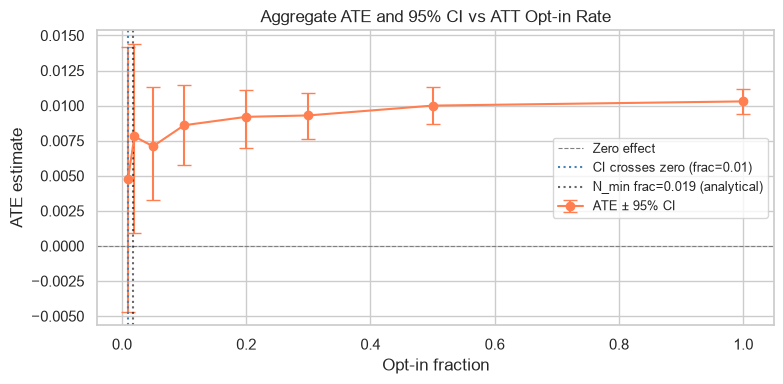

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(sweep_df["opt_in_frac"], sweep_df["ate"],
            yerr=[sweep_df["ate"] - sweep_df["ci_lo"],
                  sweep_df["ci_hi"] - sweep_df["ate"]],
            fmt="o-", color="coral", capsize=5, label="ATE ± 95% CI")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8, label="Zero effect")
if first_crossing is not None:
    ax.axvline(first_crossing, color="steelblue", linestyle=":",
               label=f"CI crosses zero (frac={first_crossing})")
ax.axvline(n_min_frac, color="black", linestyle=":", alpha=0.6,
           label=f"N_min frac={n_min_frac:.3f} (analytical)")
ax.set_xlabel("Opt-in fraction")
ax.set_ylabel("ATE estimate")
ax.set_title("Aggregate ATE and 95% CI vs ATT Opt-in Rate")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../images/att_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

The point estimate is approximately stable across opt-in rates, but the CI widens substantially. At full scale (N=1,397,960) the 95% CI is [0.0094, 0.0112] (width = 0.0019). At 20% opt-in (N=279,592) it widens to [0.0070, 0.0111] (width = 0.0041), a 2.2x increase. At 5% opt-in (N=69,898) the CI is [0.0033, 0.0113], still fully positive.

Extending the sweep to frac=0.02 and frac=0.01 reveals the zero-crossing directly. At frac=0.02 (N=27,959, just above N_min=25,991) the CI is [0.0009, 0.0144], positive but with the lower bound now within 0.001 of zero. At frac=0.01 (N=13,980, below N_min) the lower bound drops to −0.0047 (CI=[−0.0047, 0.0142]) and crosses zero; the effect is statistically indistinguishable from noise. The CI first crosses zero at frac=0.01.

The analytical N_min of 25,991 corresponds to an opt-in fraction of 0.019 (25,991 / 1,397,960), which falls between frac=0.01 and frac=0.02. The bootstrap sweep and the power formula bracket the same detection threshold; the plot marks both the first observed crossing (frac=0.01) and the analytical N_min frac (0.019), and they agree within the resolution of the sweep.

**Limitation:** random subsampling simulates only the sample-size effect of ATT. It assumes opt-in users are a random subset of all users, preserving the treatment/control ratio and the visit rate distribution. In practice, users who opt into tracking likely differ systematically from those who do not (younger, more app-engaged, higher baseline visit rates). This selection bias would shift the ATE estimate in the opted-in cohort away from the true population ATE. The results here are therefore a lower bound on measurement damage: degradation in practice will be larger than the CI widening shown above.

## 8. Summary

Three mechanisms. Each degrades measurement differently.

**Feature loss (sections 3 and 4)**
- Removing high-KS features produced a non-monotonic pattern (baseline 0.0543, highest point 0.0599 at n=9 after removing f2, f8, f9) before collapsing sharply at n=6 (0.0577 → 0.0044). The peak gain (+10%) falls within the Experiment A variance band (~0.014), so it cannot be clearly distinguished from noise at 50% scale.
- Three experiments examined the **outcome dominance** hypothesis: f8 and f2 are strong visit predictors (ROC AUC 0.94) but weaker as uplift-only features (Qini 0.0363 vs full model 0.0853). The directional mechanism holds; the light-config improvement is within noise at this scale.
- The effect is **regime-dependent**: at full scale, removing f8/f2 costs ~2% Qini rather than gaining. Dominance harm is more likely to activate as training data degrades further, making feature selection relatively more important under ATT conditions.

**SKAN threshold censoring (section 5)**
- Censoring is MNAR: cohorts are dropped because their visit count is low, not at random.
- The control arm (lower base visit rate) loses cohorts faster, compressing the ATE estimate downward.
- At small cohort sizes (k=50), a moderate threshold (t=5) causes 91% data loss and reduces ATE from 0.0103 to 0.0026 (75% downward bias). At 10% scale the same configuration produced sign reversal; at 50% scale the estimate stabilizes without flipping because more cohorts reduce partition variance.

**Statistical power and aggregate measurement (sections 6 and 7)**
- Detecting the observed effect requires roughly 26,000 users; the 85/15 allocation raises this ~2x vs a balanced experiment (the 1.4x MDE penalty squared).
- Aggregate ATE is approximately stable across opt-in rates; CI width grows 2.2x at 20% opt-in and the effect becomes statistically invisible below approximately 2% opt-in (N < N_min = 25,991).

**What survives ATT:**

| Capability | Pre-ATT | Post-ATT | Evidence |
|---|---|---|---|
| Per-user uplift ranking | Works | Breaks as features are lost | Sections 3-4 |
| CATE-based budget policy | Works | Degrades in data-constrained regimes | Section 4 |
| Aggregate incrementality | Works | Survives above N_min (~26K users); biased under threshold censoring | Sections 5-7 |